In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as p
import numpy as np
import flamingo_analysis as fa 
import tangos as db

def test_stellar_mass_sfr_relation(tsnum=8):
    p.figure(figsize=(18,5))
    db.init_db('data-720.db')
    sfr, mstar, m200m = db.get_timestep(f"L0200N0720_HYDRO_FIDUCIAL/%{tsnum}.hdf5").calculate_all("InclusiveSphere_30kpc_StarFormationRate*0.0102", "InclusiveSphere_30kpc_StellarMass*1e10", "M200m()")
    s_sfr = sfr/mstar
    p.subplot(131)
    mask = m200m>2e12 
    s_sfr[s_sfr<1e-13] = 1e-13
    sfr[sfr<0.01] = 0.01
    p.plot(np.log10(m200m[mask]), np.log10(mstar[mask]), 'r.')
    p.subplot(132)
    p.plot(np.log10(mstar[mask]), np.log10(sfr[mask]), 'r.')
    p.subplot(133)
    p.plot(np.log10(mstar[mask]), np.log10(s_sfr[mask]), 'r.')

    db.init_db('data.db')
    sfr, mstar, m200m = db.get_timestep(f"L0200N0360_HYDRO_FIDUCIAL/%{tsnum}.hdf5").calculate_all("InclusiveSphere_30kpc_StarFormationRate*0.0102", "InclusiveSphere_30kpc_StellarMass*1e10", "M200m()")
    s_sfr = sfr/mstar
    s_sfr[s_sfr<1e-13] = 1e-13
    sfr[sfr<0.01] = 0.01
    mask = m200m>2e12 
    p.subplot(131)
    p.plot(np.log10(m200m[mask]), np.log10(mstar[mask]), 'g.')
    p.subplot(132)
    p.plot(np.log10(mstar[mask]), np.log10(sfr[mask]), 'g.')
    p.subplot(133)
    p.plot(np.log10(mstar[mask]), np.log10(s_sfr[mask]), 'g.')

    redshift = db.get_timestep(f'L0200N0360_HYDRO_FIDUCIAL/%{tsnum}.hdf5').redshift

    p.subplot(131)
    p.legend(['high-res', 'low-res'])
    p.xlabel(r"$\log_{10}(M_{200m}/M_\odot)$")
    p.ylabel(r"$\log_{10}(M_\star/M_\odot)$")
    p.title(f"z={redshift:.1f}")

    p.subplot(132)
    p.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
    p.ylabel(r"$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$")
    p.title(f"z={redshift:.1f}")

    p.subplot(133)
    p.xlabel(r"$\log_{10}(M_\star/M_\odot)$")
    p.ylabel(r"$\log_{10}(\mathrm{sSFR}/\mathrm{yr}^{-1})$")
    p.gca().yaxis.tick_right()
    p.gca().yaxis.set_label_position("right")
    p.title(f"z={redshift:.1f}")
    p.tight_layout()

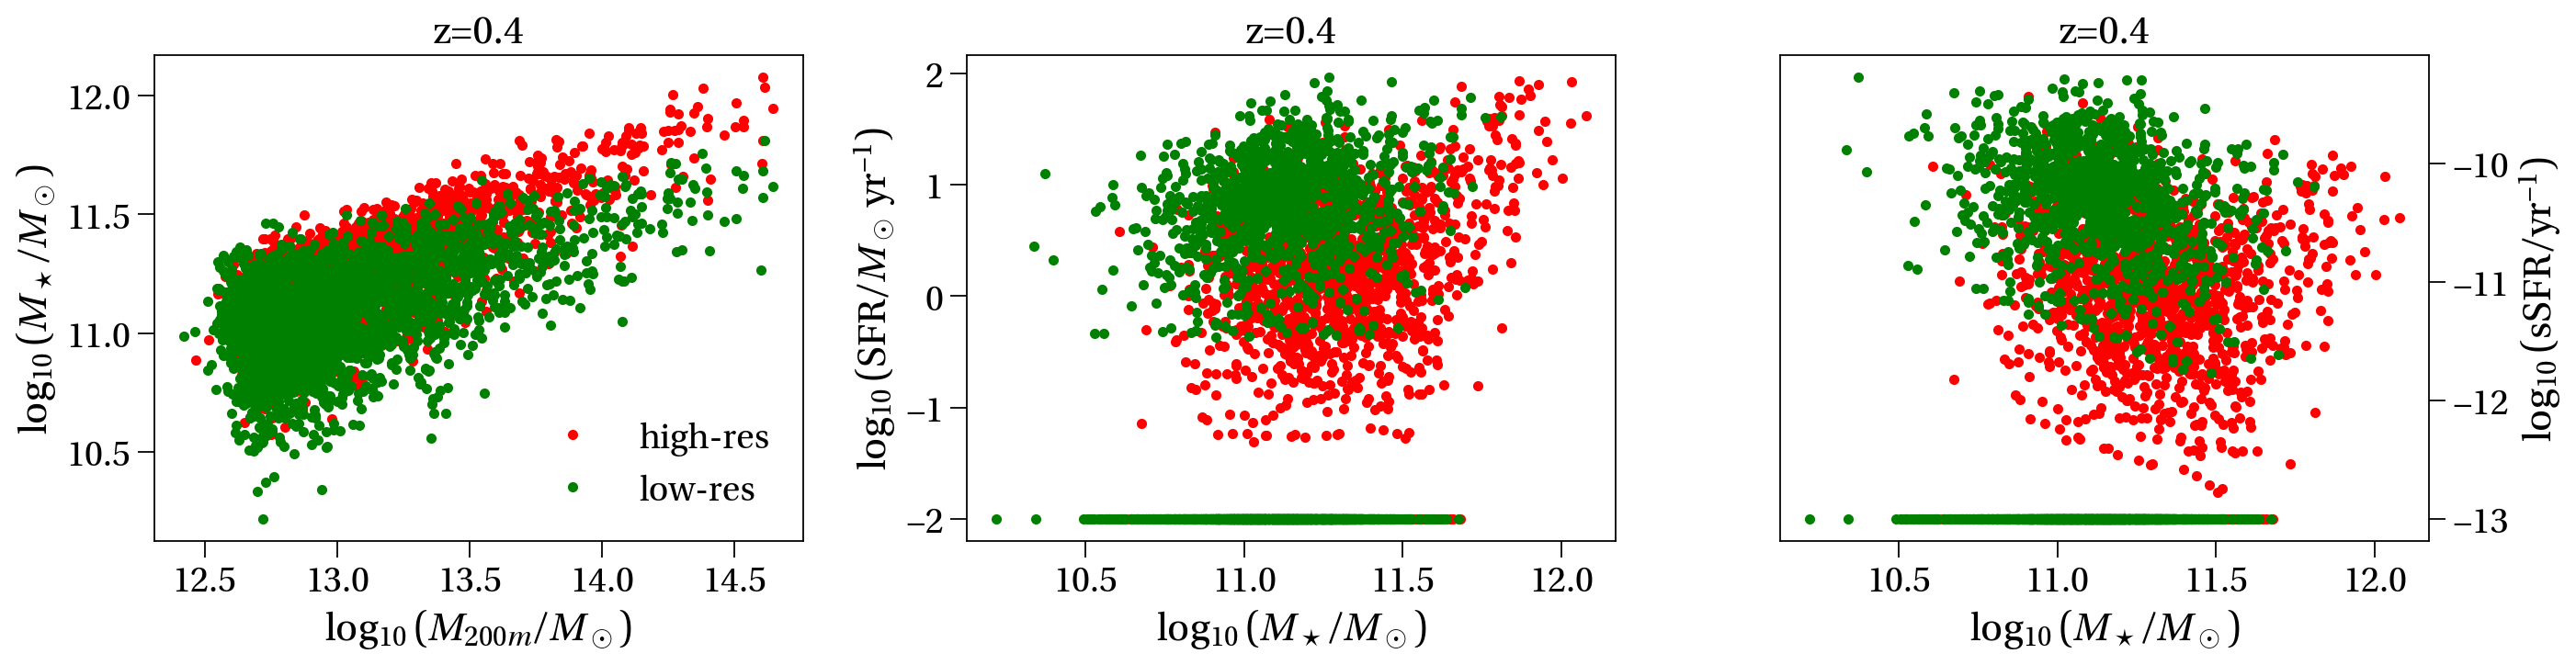

In [2]:
test_stellar_mass_sfr_relation(4)

In [5]:
def test_gas_mass_profiles(M_name='M200m()', M_range=(12.5, 13.5), tsnum=4):
    fa.ranges=[M_range]
    fa.mass_name=M_name

    match M_name:
        case 'InclusiveSphere_30kpc_StellarMass*1e10':
            M_name_latex = r"M_{\mathrm{stellar}}"
        case 'M200m()':
            M_name_latex = r"M_{200m}"

    db.init_db('data.db')
    fa.make_profile_plots_with_cut('mass_enclosed', 'InclusiveSphere_30kpc_StarFormationRate*0.0102', cut_value=1.0,
                                tsnum=tsnum, box="L0200N0360_HYDRO_FIDUCIAL", plot_kwargs={'color':'g', 'label' : 'low-res'})
    redshift = db.get_timestep(f'L0200N0360_HYDRO_FIDUCIAL/%{tsnum}.hdf5').redshift
    db.init_db('data-720.db')
    fa.make_profile_plots_with_cut('mass_enclosed', 'InclusiveSphere_30kpc_StarFormationRate*0.0102', cut_value=1.0,
                                tsnum=tsnum, box="L0200N0720_HYDRO_FIDUCIAL", plot_kwargs={'color':'r', 'label' : 'high-res'}, newfig=False)

    
    p.subplot(121)
    p.title(rf"$z={redshift:.1f}$, $10^{{{M_range[0]}}} < {M_name_latex}/M_\odot < 10^{{{M_range[1]}}}$")
    p.subplot(122)
    fa.remove_existing_legend()
    p.title(rf"$z={redshift:.1f}$, $10^{{{M_range[0]}}} < {M_name_latex}/M_\odot < 10^{{{M_range[1]}}}$")

Plotting mass_enclosed profiles for L0200N0360_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0360_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


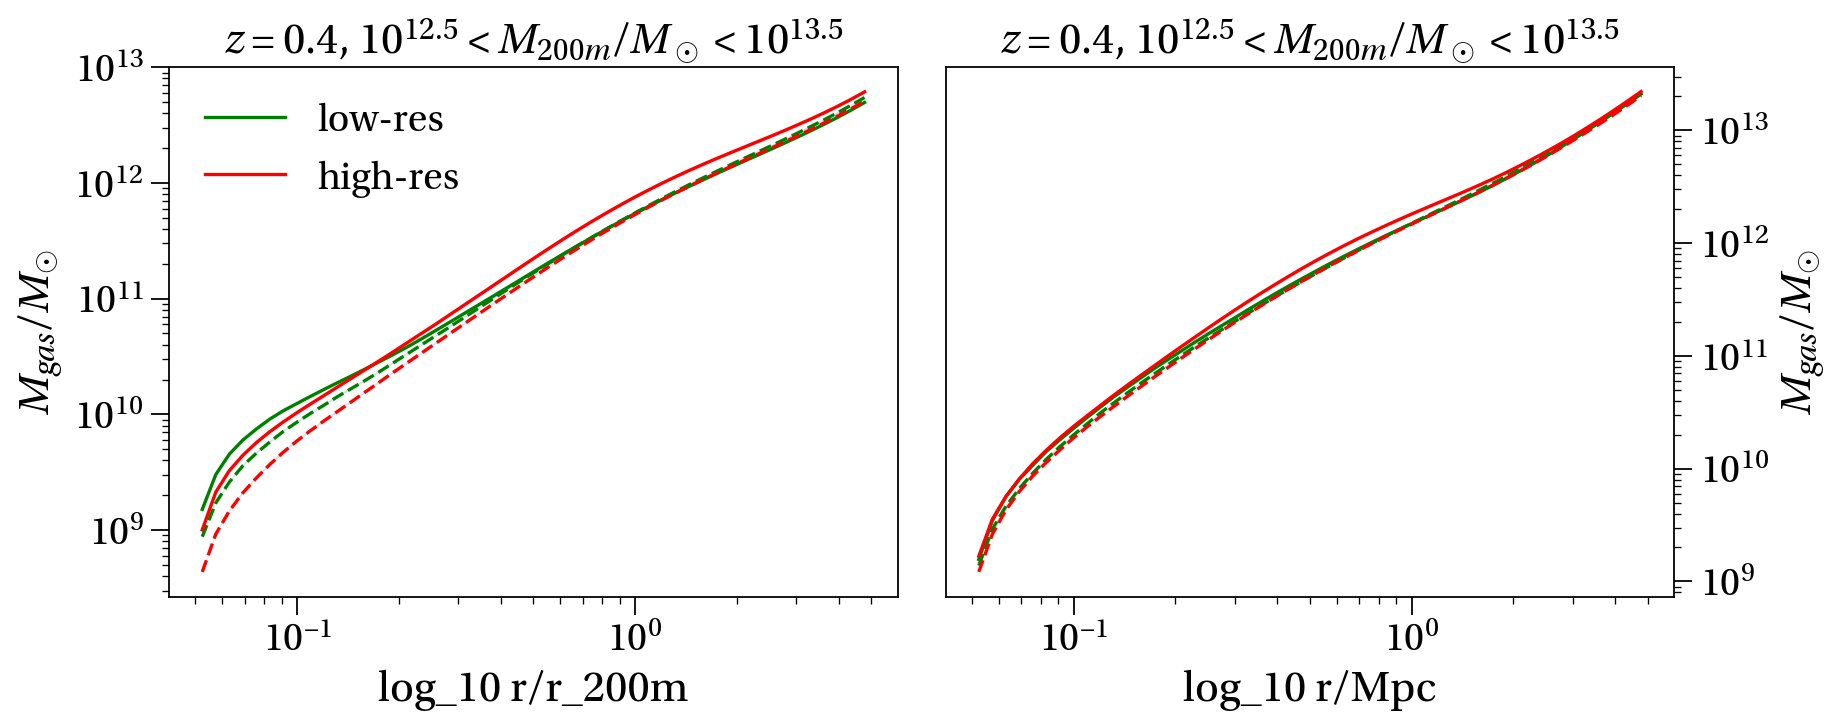

In [7]:
test_gas_mass_profiles()

Plotting mass_enclosed profiles for L0200N0360_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0360_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5
Plotting mass_enclosed profiles for L0200N0720_HYDRO_FIDUCIAL/%4.hdf5


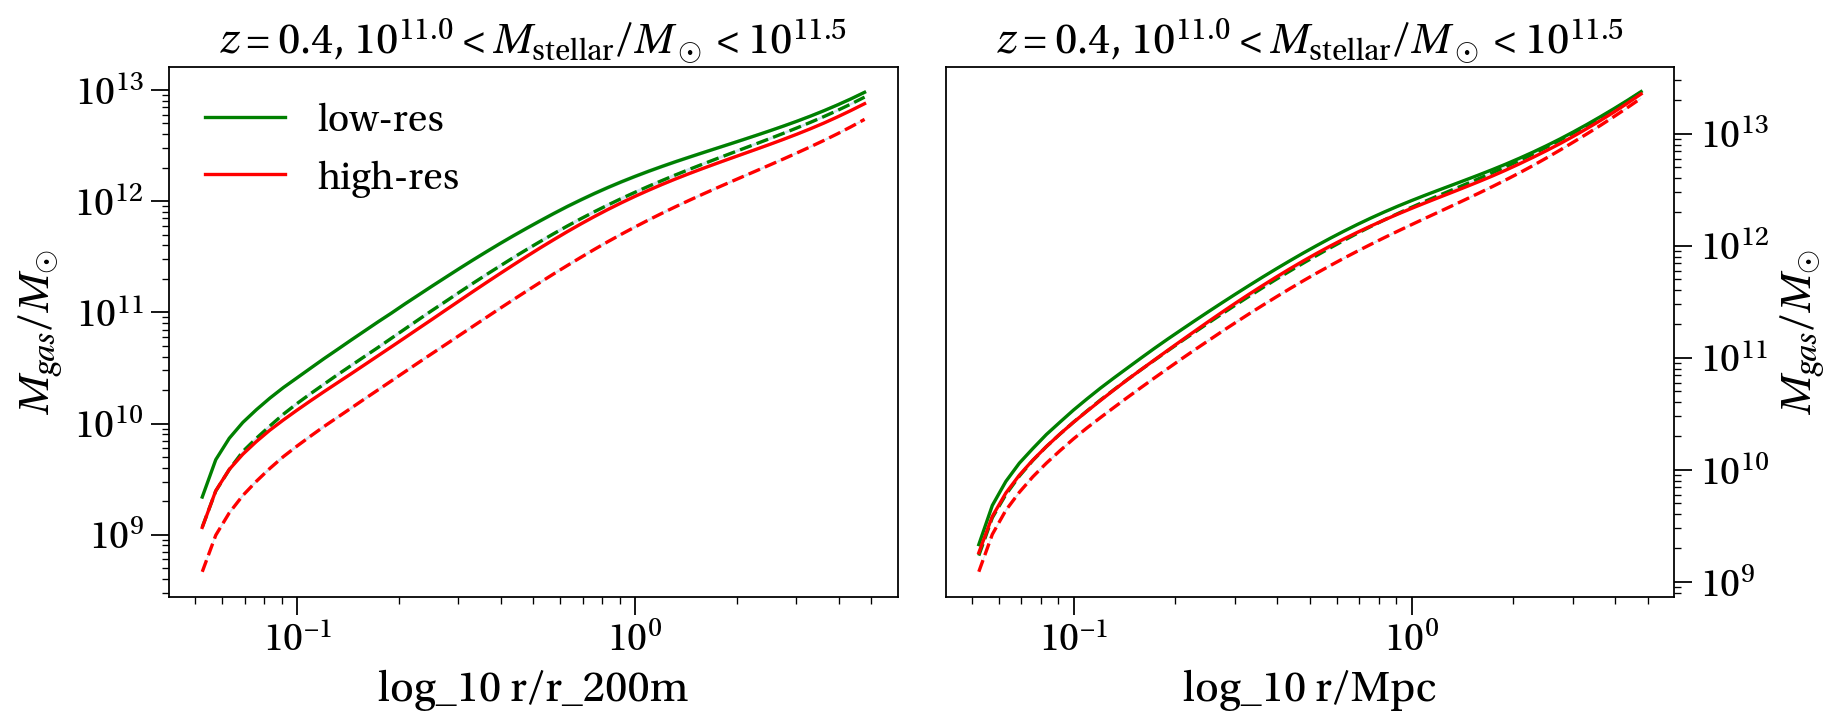

In [6]:
test_gas_mass_profiles('InclusiveSphere_30kpc_StellarMass*1e10', (11.0, 11.5), tsnum=4)